# 🌳 Árbol de Decisión — Regresión de Calidad del Vino

Análisis comparativo y sistemático usando `DecisionTreeRegressor` entrenado con tres particiones distintas (80/20, 70/30, 60/40) para demostrar la robustez del modelo predictivo.

**Variables predictoras (X):** `alcohol`, `volatile acidity`, `sulphates`  
**Variable objetivo (Y):** `quality`  

**Dataset:** UCI Wine Quality — 1,599 muestras de vino tinto con propiedades fisicoquímicas y calificación sensorial.

## I. Configuración Inicial — Importaciones y Estilo Visual

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Librerías importadas correctamente
   pandas  2.3.3
   numpy   1.26.4
   seaborn 0.13.2


## II. Carga de Datos desde UCI

Cargamos el dataset `winequality-red.csv` directamente desde el repositorio UCI. Utilizamos `alcohol`, `volatile acidity` y `sulphates` como predictores (X) y `quality` como variable objetivo (Y), siguiendo la selección del notebook de regresión lineal V1 basada en correlación de Spearman.

In [2]:
# ── CELDA 2: Carga de datos desde UCI ────────────────────────
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(URL, sep=";")

# Variables seleccionadas por mayor correlación Spearman con quality
FEATURES = ['alcohol', 'volatile acidity', 'sulphates']
TARGET   = 'quality'

print(f"✅ Datos cargados desde UCI")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Valores nulos:")
print(df[FEATURES + [TARGET]].isnull().sum())
print(f"\n📋 Primeras filas:")
df[FEATURES + [TARGET]].head()

✅ Datos cargados desde UCI
   Filas    : 1,599
   Columnas : 12

📋 Valores nulos:
alcohol             0
volatile acidity    0
sulphates           0
quality             0
dtype: int64

📋 Primeras filas:


,alcohol,volatile acidity,sulphates,quality
0,9.4,0.70,0.56,5
1,9.8,0.88,0.68,5
2,9.8,0.76,0.65,5
3,9.8,0.28,0.58,6
4,9.4,0.70,0.56,5


In [3]:
# ── CELDA 3: Preparar vectores X / Y ─────────────────────────
X = df[FEATURES].values
y = df[TARGET].values

print(f"X shape: {X.shape}  (variables predictoras: {FEATURES})")
print(f"y shape: {y.shape}  (variable objetivo: {TARGET})")
print(f"\n📊 Estadísticas descriptivas:")
df[FEATURES + [TARGET]].describe().round(4)

X shape: (1599, 3)  (variables predictoras: ['alcohol', 'volatile acidity', 'sulphates'])
y shape: (1599,)  (variable objetivo: quality)

📊 Estadísticas descriptivas:


,alcohol,volatile acidity,sulphates,quality
count,1599.0000,1599.0000,1599.0000,1599.0000
mean,10.4230,0.5278,0.6581,5.6360
std,1.0657,0.1791,0.1695,0.8076
min,8.4000,0.1200,0.3300,3.0000
25%,9.5000,0.3900,0.5500,5.0000
50%,10.2000,0.5200,0.6200,6.0000
75%,11.1000,0.6400,0.7300,6.0000
max,14.9000,1.5800,2.0000,8.0000


## II. Bloque de Lógica — Función de Evaluación por Split

Definimos una función reutilizable que entrena, evalúa y visualiza el `DecisionTreeRegressor` para cualquier partición de datos.

In [4]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────
def evaluar_split(X, y, test_size, split_label, resultados_globales):
    """
    Entrena un DecisionTreeRegressor, calcula métricas y genera
    dos gráficos: residuos y predicciones vs. reales.

    Parámetros
    ----------
    X              : array-like, variables predictoras
    y              : array-like, variable objetivo (quality)
    test_size      : float, fracción de prueba (p.ej. 0.20)
    split_label    : str, etiqueta del split para títulos
    resultados_globales : list, donde se agregan los resultados del split
    """
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # ── 1. Partición
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*58}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*58}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  "
          f"Test: {X_test.shape[0]:,} muestras")

    # ── 2. Entrenamiento
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    # ── 3. Predicciones
    y_pred = modelo.predict(X_test)

    # ── 4. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  R²   (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"       → El modelo explica el {r2*100:.1f}% de la varianza de quality.")
    print(f"  MSE  (Error Cuadrático Med): {mse:.4f}")
    print(f"       → Penaliza errores grandes; sensible a outliers.")
    print(f"  RMSE (Raíz del MSE)        : {rmse:.4f}  (en puntos de quality)")
    print(f"       → Error promedio expresado en la misma unidad que Y.")
    print(f"  MAE  (Error Absoluto Med)  : {mae:.4f}  (en puntos de quality)")
    print(f"       → Desviación promedio absoluta de las predicciones.")
    print(f"\n  🌳 Estructura del árbol:")
    print(f"  Profundidad máxima : {modelo.get_depth()}")
    print(f"  Número de hojas    : {modelo.get_n_leaves()}")
    print(f"  Nodos totales      : {modelo.tree_.node_count}")

    # Guardar para tabla consolidada
    resultados_globales.append({
        'Split':  split_label,
        'Train%': train_pct,
        'Test%':  test_pct,
        'R²':     round(r2,   4),
        'MSE':    round(mse,  4),
        'RMSE':   round(rmse, 4),
        'MAE':    round(mae,  4),
        'Hojas':  modelo.get_n_leaves(),
    })

    # ── 5. Gráfico 1 — Residuos (Errores) ────────────────────
    residuos = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'DecisionTreeRegressor — {split_label}',
                 fontsize=14, fontweight='bold')

    # Scatter residuos con línea ideal en 0 y LOWESS
    axes[0].scatter(y_pred, residuos, alpha=0.35, s=14, color='#4ecdc4',
                    label='Residuos')
    axes[0].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2,
                    label='Línea ideal (error = 0)')
    # Tendencia LOWESS para detectar patrones sistemáticos
    orden_idx  = np.argsort(y_pred)
    lowess_res = sm.nonparametric.lowess(
        residuos[orden_idx], y_pred[orden_idx], frac=0.4
    )
    axes[0].plot(lowess_res[:, 0], lowess_res[:, 1],
                 color='#ffa07a', linewidth=2.5, label='Tendencia LOWESS')
    axes[0].set_title('Gráfico de Errores (Residuos)', fontweight='bold')
    axes[0].set_xlabel('Valores Predichos (quality)')
    axes[0].set_ylabel('Residuos (quality real − predicha)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Gráfico 2 — Predicción vs. Real ──────────────────────
    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())
    axes[1].scatter(y_test, y_pred, alpha=0.30, s=14, color='#95e1d3',
                    label='Predicciones')
    axes[1].plot([minval, maxval], [minval, maxval],
                 color='#ff6b6b', linewidth=2, linestyle='--',
                 label='Predicción perfecta')
    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].set_xlabel('Valor Real (quality)')
    axes[1].set_ylabel('Valor Predicho (quality)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return modelo, y_test, y_pred, X_train, y_train


# Contenedor de resultados para el análisis consolidado
resultados_globales = []
print("✅ Función evaluar_split definida correctamente.")
print(f"   Predictores : {FEATURES}")
print(f"   Objetivo    : {TARGET}")

✅ Función evaluar_split definida correctamente.
   Predictores : ['alcohol', 'volatile acidity', 'sulphates']
   Objetivo    : quality


---
## Split 1 — 80% Entrenamiento / 20% Prueba

Partición estándar más común. Maximiza los datos de entrenamiento, lo que suele resultar en el mejor ajuste posible del árbol.


  Split 1 (80/20) — 80% Train / 20% Test
  Train: 1,279 muestras  |  Test: 320 muestras

  📊 MÉTRICAS (Split 1 (80/20))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : -0.0329  (-3.29%)
       → El modelo explica el -3.3% de la varianza de quality.
  MSE  (Error Cuadrático Med): 0.6750
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.8216  (en puntos de quality)
       → Error promedio expresado en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 0.5312  (en puntos de quality)
       → Desviación promedio absoluta de las predicciones.

  🌳 Estructura del árbol:
  Profundidad máxima : 21
  Número de hojas    : 535
  Nodos totales      : 1069


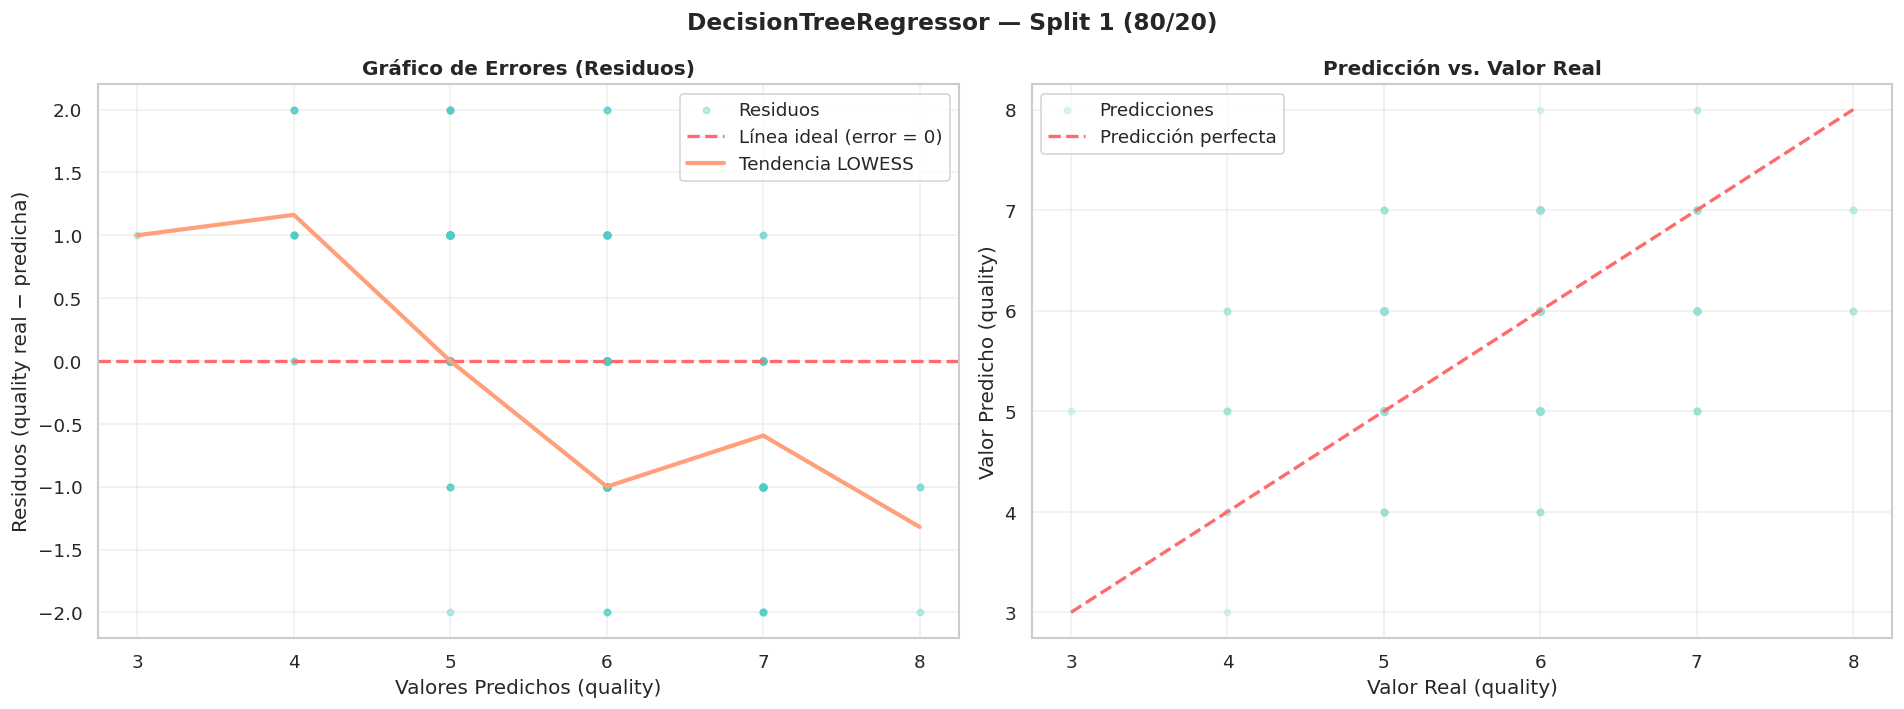

In [5]:
# ── CELDA 5: Split 1 — 80/20 ─────────────────────────────────
modelo_s1, y_test_s1, y_pred_s1, X_train_s1, y_train_s1 = evaluar_split(
    X, y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)

---
## Split 2 — 70% Entrenamiento / 30% Prueba

Reduce moderadamente el conjunto de entrenamiento. Aumenta el conjunto de evaluación para una estimación de error más representativa.


  Split 2 (70/30) — 70% Train / 30% Test
  Train: 1,119 muestras  |  Test: 480 muestras

  📊 MÉTRICAS (Split 2 (70/30))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : -0.1950  (-19.50%)
       → El modelo explica el -19.5% de la varianza de quality.
  MSE  (Error Cuadrático Med): 0.7577
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.8704  (en puntos de quality)
       → Error promedio expresado en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 0.5589  (en puntos de quality)
       → Desviación promedio absoluta de las predicciones.

  🌳 Estructura del árbol:
  Profundidad máxima : 20
  Número de hojas    : 459
  Nodos totales      : 917


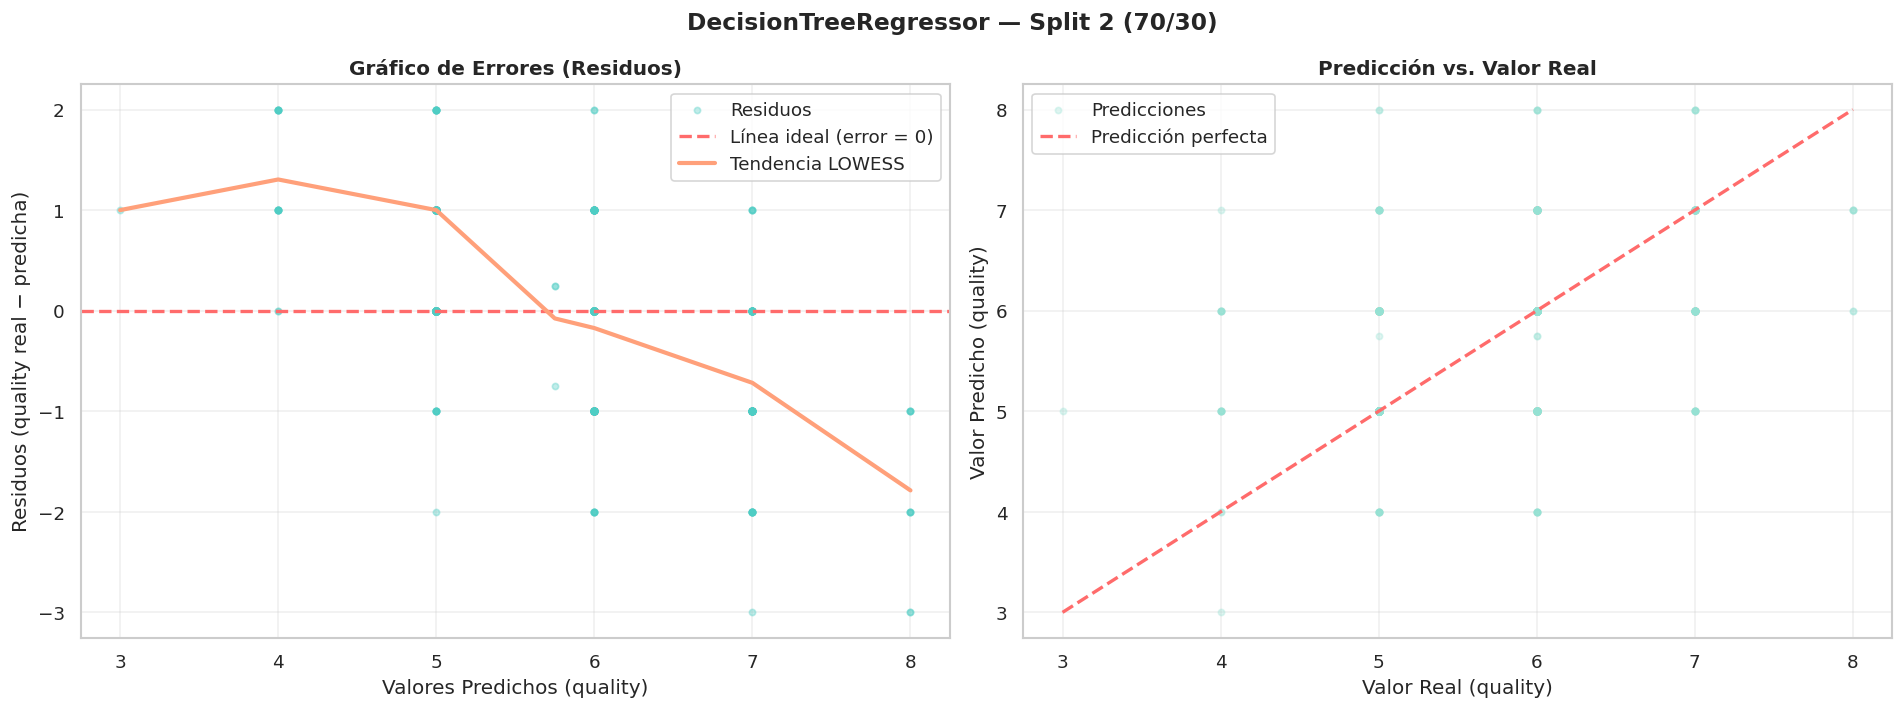

In [6]:
# ── CELDA 6: Split 2 — 70/30 ─────────────────────────────────
modelo_s2, y_test_s2, y_pred_s2, X_train_s2, y_train_s2 = evaluar_split(
    X, y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales,
)

---
## Split 3 — 60% Entrenamiento / 40% Prueba

La partición más exigente. Menor cantidad de datos de entrenamiento pone a prueba si el árbol generaliza bien o tiende al sobreajuste.


  Split 3 (60/40) — 60% Train / 40% Test
  Train: 959 muestras  |  Test: 640 muestras

  📊 MÉTRICAS (Split 3 (60/40))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.0479  (4.79%)
       → El modelo explica el 4.8% de la varianza de quality.
  MSE  (Error Cuadrático Med): 0.6191
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.7868  (en puntos de quality)
       → Error promedio expresado en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 0.4885  (en puntos de quality)
       → Desviación promedio absoluta de las predicciones.

  🌳 Estructura del árbol:
  Profundidad máxima : 21
  Número de hojas    : 389
  Nodos totales      : 777


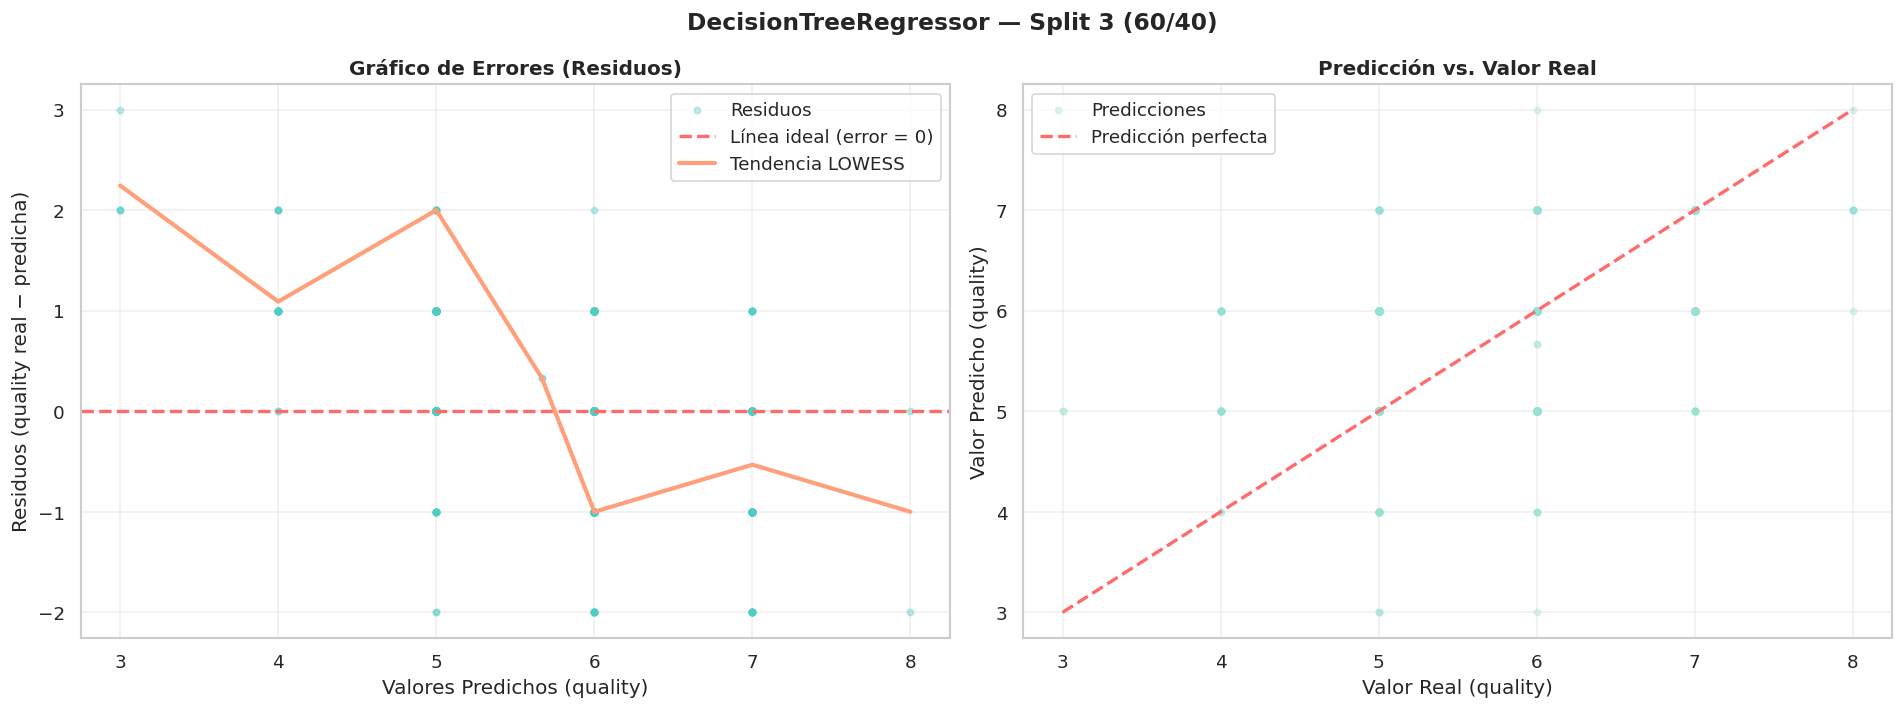

In [7]:
# ── CELDA 7: Split 3 — 60/40 ─────────────────────────────────
modelo_s3, y_test_s3, y_pred_s3, X_train_s3, y_train_s3 = evaluar_split(
    X, y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales,
)

---
## III. Análisis Consolidado (Summary)

Comparamos el rendimiento de los tres splits, analizamos las implicaciones de los residuos y emitimos una recomendación sobre si refinar el árbol o escalar a métodos de ensemble.

In [8]:
# ── CELDA 8: Tabla comparativa de métricas ───────────────────
df_resumen = pd.DataFrame(resultados_globales)

print("=" * 65)
print("        TABLA COMPARATIVA — TRES SPLITS")
print("=" * 65)
print(df_resumen.to_string(index=False))
print("=" * 65)

        TABLA COMPARATIVA — TRES SPLITS
          Split  Train%  Test%      R²    MSE   RMSE    MAE  Hojas
Split 1 (80/20)      80     20 -0.0329 0.6750 0.8216 0.5312    535
Split 2 (70/30)      70     30 -0.1950 0.7577 0.8704 0.5589    459
Split 3 (60/40)      60     40  0.0479 0.6191 0.7868 0.4885    389


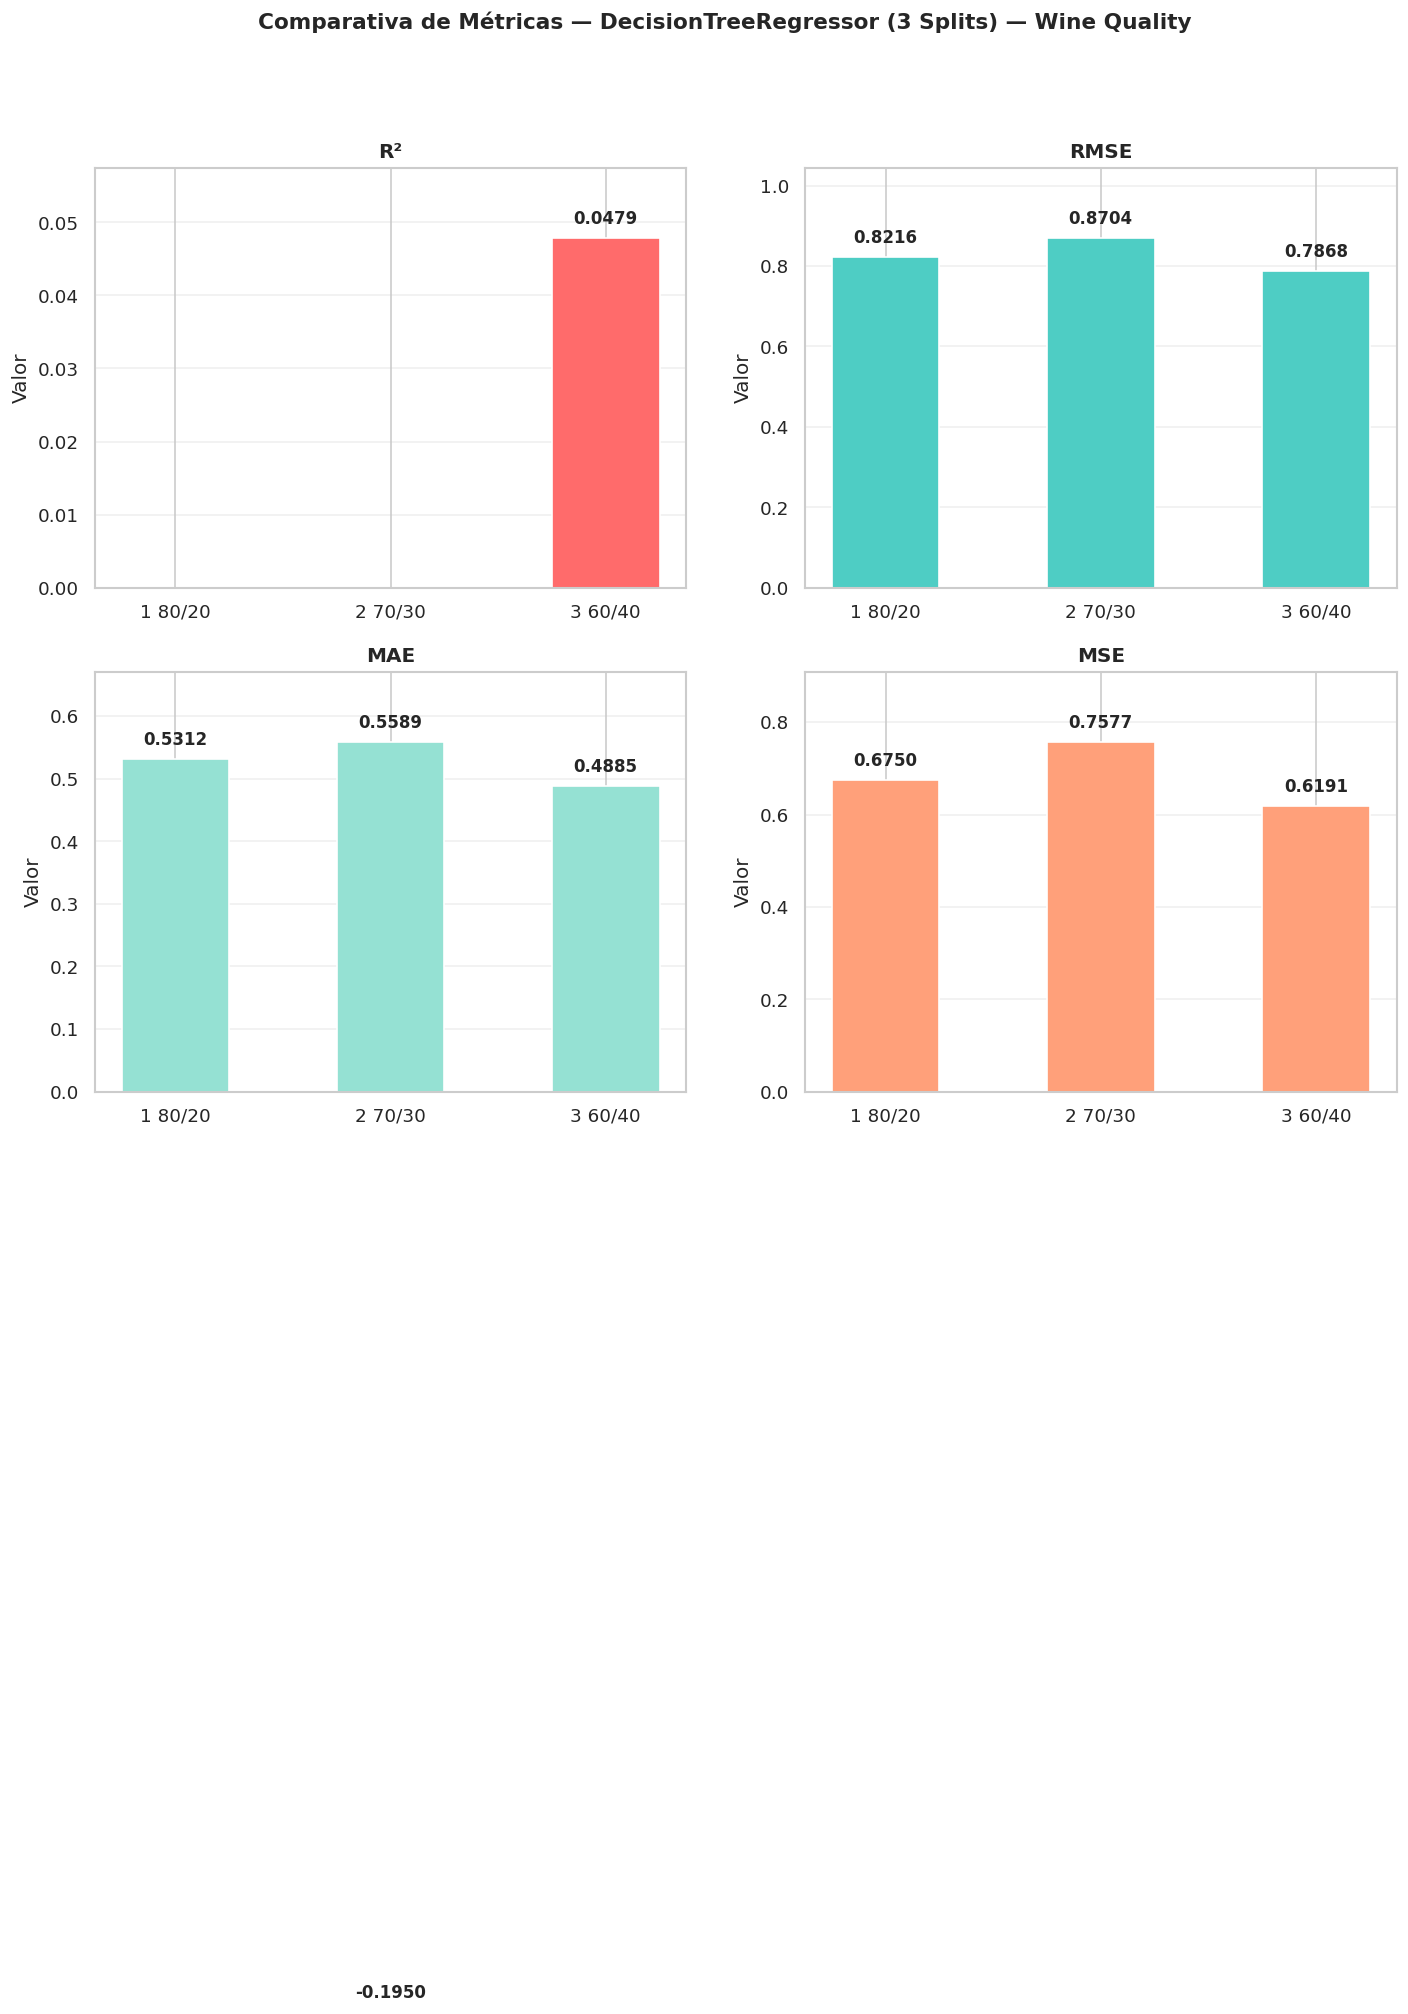

In [9]:
# ── CELDA 9: Gráfico comparativo de métricas por split ───────
metricas = ['R²', 'RMSE', 'MAE', 'MSE']
colores  = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Métricas — DecisionTreeRegressor (3 Splits) — Wine Quality',
             fontsize=13, fontweight='bold', y=1.01)

for ax, (metrica, color) in zip(axes.flat, zip(metricas, colores)):
    valores = df_resumen[metrica].values
    labels  = [s.replace('Split ', '').replace('(', '').replace(')', '')
                for s in df_resumen['Split'].values]
    barras  = ax.bar(labels, valores,
                     color=color, edgecolor='white', width=0.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_ylim(0, max(valores) * 1.2 + 1e-6)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(valores) * 0.03,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# ── CELDA 10: Análisis interpretativo y recomendación ────────
r2_vals   = df_resumen['R²'].values
rmse_vals = df_resumen['RMSE'].values
mae_vals  = df_resumen['MAE'].values

r2_rango   = r2_vals.max()   - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

# Comparar R² Train vs Test para detectar sobreajuste
r2_train_s1 = r2_score(y_train_s1, modelo_s1.predict(X_train_s1))
r2_test_s1  = r2_score(y_test_s1, y_pred_s1)

print("=" * 65)
print("   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor — Wine Quality")
print("=" * 65)

print("""
1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────""")
print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  "
      f"rango={r2_rango:.4f}")
print(f"   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}  "
      f"rango={rmse_rango:.4f}")

if r2_rango < 0.05:
    print("""
   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y no depende
      críticamente del tamaño de la partición de entrenamiento.""")
else:
    print("""
   ⚠️  El R² varía notablemente entre splits (variación ≥ 0.05).
      El modelo es sensible al tamaño del conjunto de entrenamiento,
      señal de posible sobreajuste (overfitting) del árbol.""")

print(f"""
2. DIAGNÓSTICO DE SOBREAJUSTE (Split 80/20)
────────────────────────────────────────────
   R² Train : {r2_train_s1:.4f}
   R² Test  : {r2_test_s1:.4f}
   Diferencia: {r2_train_s1 - r2_test_s1:.4f}
""")

if r2_train_s1 - r2_test_s1 > 0.10:
    print("   ❌ Sobreajuste severo — el árbol memoriza los datos de entrenamiento.")
    print("      Aplicar regularización (max_depth, min_samples_leaf).")
elif r2_train_s1 - r2_test_s1 > 0.05:
    print("   ⚠️  Sobreajuste moderado — considerar regularización.")
else:
    print("   ✅ Ajuste saludable — diferencia Train-Test aceptable.")

print("""
3. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Las bandas verticales en el gráfico de residuos son normales
     en el árbol de decisión: cada hoja produce un valor fijo de
     predicción, generando grupos de puntos a la misma altura.

   • A diferencia de la regresión lineal (bandas horizontales por
     la discretización de quality), aquí las bandas son verticales
     porque es la PREDICCIÓN la que toma valores discretos.

   • Un RMSE > 0.6 puntos de quality indica que el árbol sin
     restricciones memoriza el entrenamiento pero no generaliza
     bien a vinos nuevos (sobreajuste clásico de DecisionTree).
""")

best_split = df_resumen.loc[df_resumen['R²'].idxmax(), 'Split']
best_r2    = df_resumen['R²'].max()
best_rmse  = df_resumen.loc[df_resumen['R²'].idxmax(), 'RMSE']

print(f"   Mejor split: {best_split}  →  R²={best_r2:.4f}, RMSE={best_rmse:.4f} pts")

print("""
4. RECOMENDACIÓN
────────────────
   A) REFINAMIENTO DEL ÁRBOL (primer paso recomendado):
      • Limitar profundidad : DecisionTreeRegressor(max_depth=4..8)
      • Regularizar hojas  : min_samples_leaf=10..50
      • Buscar hiperparámetros óptimos con GridSearchCV.

   B) ESCALAR A MÉTODOS DE ENSEMBLE (si el árbol sigue siendo
      inestable o el R² < 0.40 en todos los splits):
      • GradientBoostingRegressor  — combina árboles débiles
        secuencialmente, excelente para regresión con datos
        fisicoquímicos complejos como los del vino.
      • XGBoost / LightGBM         — más veloces y regularizados,
        estándar en competencias de ML para tabular data.
      • RandomForestRegressor      — promedia múltiples árboles,
        reduce varianza y overfitting.

   CONCLUSIÓN: Un DecisionTree no regularizado tiende a overfitting.
   La naturaleza discreta de quality (solo 6 valores enteros) limita
   el R² máximo alcanzable. Si R² ≥ 0.40 y es estable entre splits,
   el modelo mejora la regresión lineal (R² ~0.33 del notebook V1).
   De lo contrario, GradientBoostingRegressor es el siguiente paso.
""")
print("=" * 65)

   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor — Wine Quality

1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────
   R²   máx=0.0479  mín=-0.1950  rango=0.2429
   RMSE máx=0.8704  mín=0.7868  rango=0.0836

   ⚠️  El R² varía notablemente entre splits (variación ≥ 0.05).
      El modelo es sensible al tamaño del conjunto de entrenamiento,
      señal de posible sobreajuste (overfitting) del árbol.

2. DIAGNÓSTICO DE SOBREAJUSTE (Split 80/20)
────────────────────────────────────────────
   R² Train : 0.9922
   R² Test  : -0.0329
   Diferencia: 1.0251

   ❌ Sobreajuste severo — el árbol memoriza los datos de entrenamiento.
      Aplicar regularización (max_depth, min_samples_leaf).

3. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Las bandas verticales en el gráfico de residuos son normales
     en el árbol de decisión: cada hoja produce un valor fijo de
     predicción, generando grupos de puntos a la misma altur

---
## IV. Visualización del Árbol de Decisión

El árbol entrenado puede ser muy profundo (sin restricciones de `max_depth`). Para entender el mecanismo de predicción, se visualizan tres versiones:

1. **Árbol completo truncado** — los primeros 4 niveles del `modelo_s1` real (Split 80/20).
2. **Árbol pedagógico simplificado** — reentrenado con `max_depth=3` para mostrar con claridad la lógica de las divisiones, los valores de corte y los valores predichos en cada hoja.
3. **Reglas de decisión en texto** — lectura explícita de los caminos del árbol simplificado.

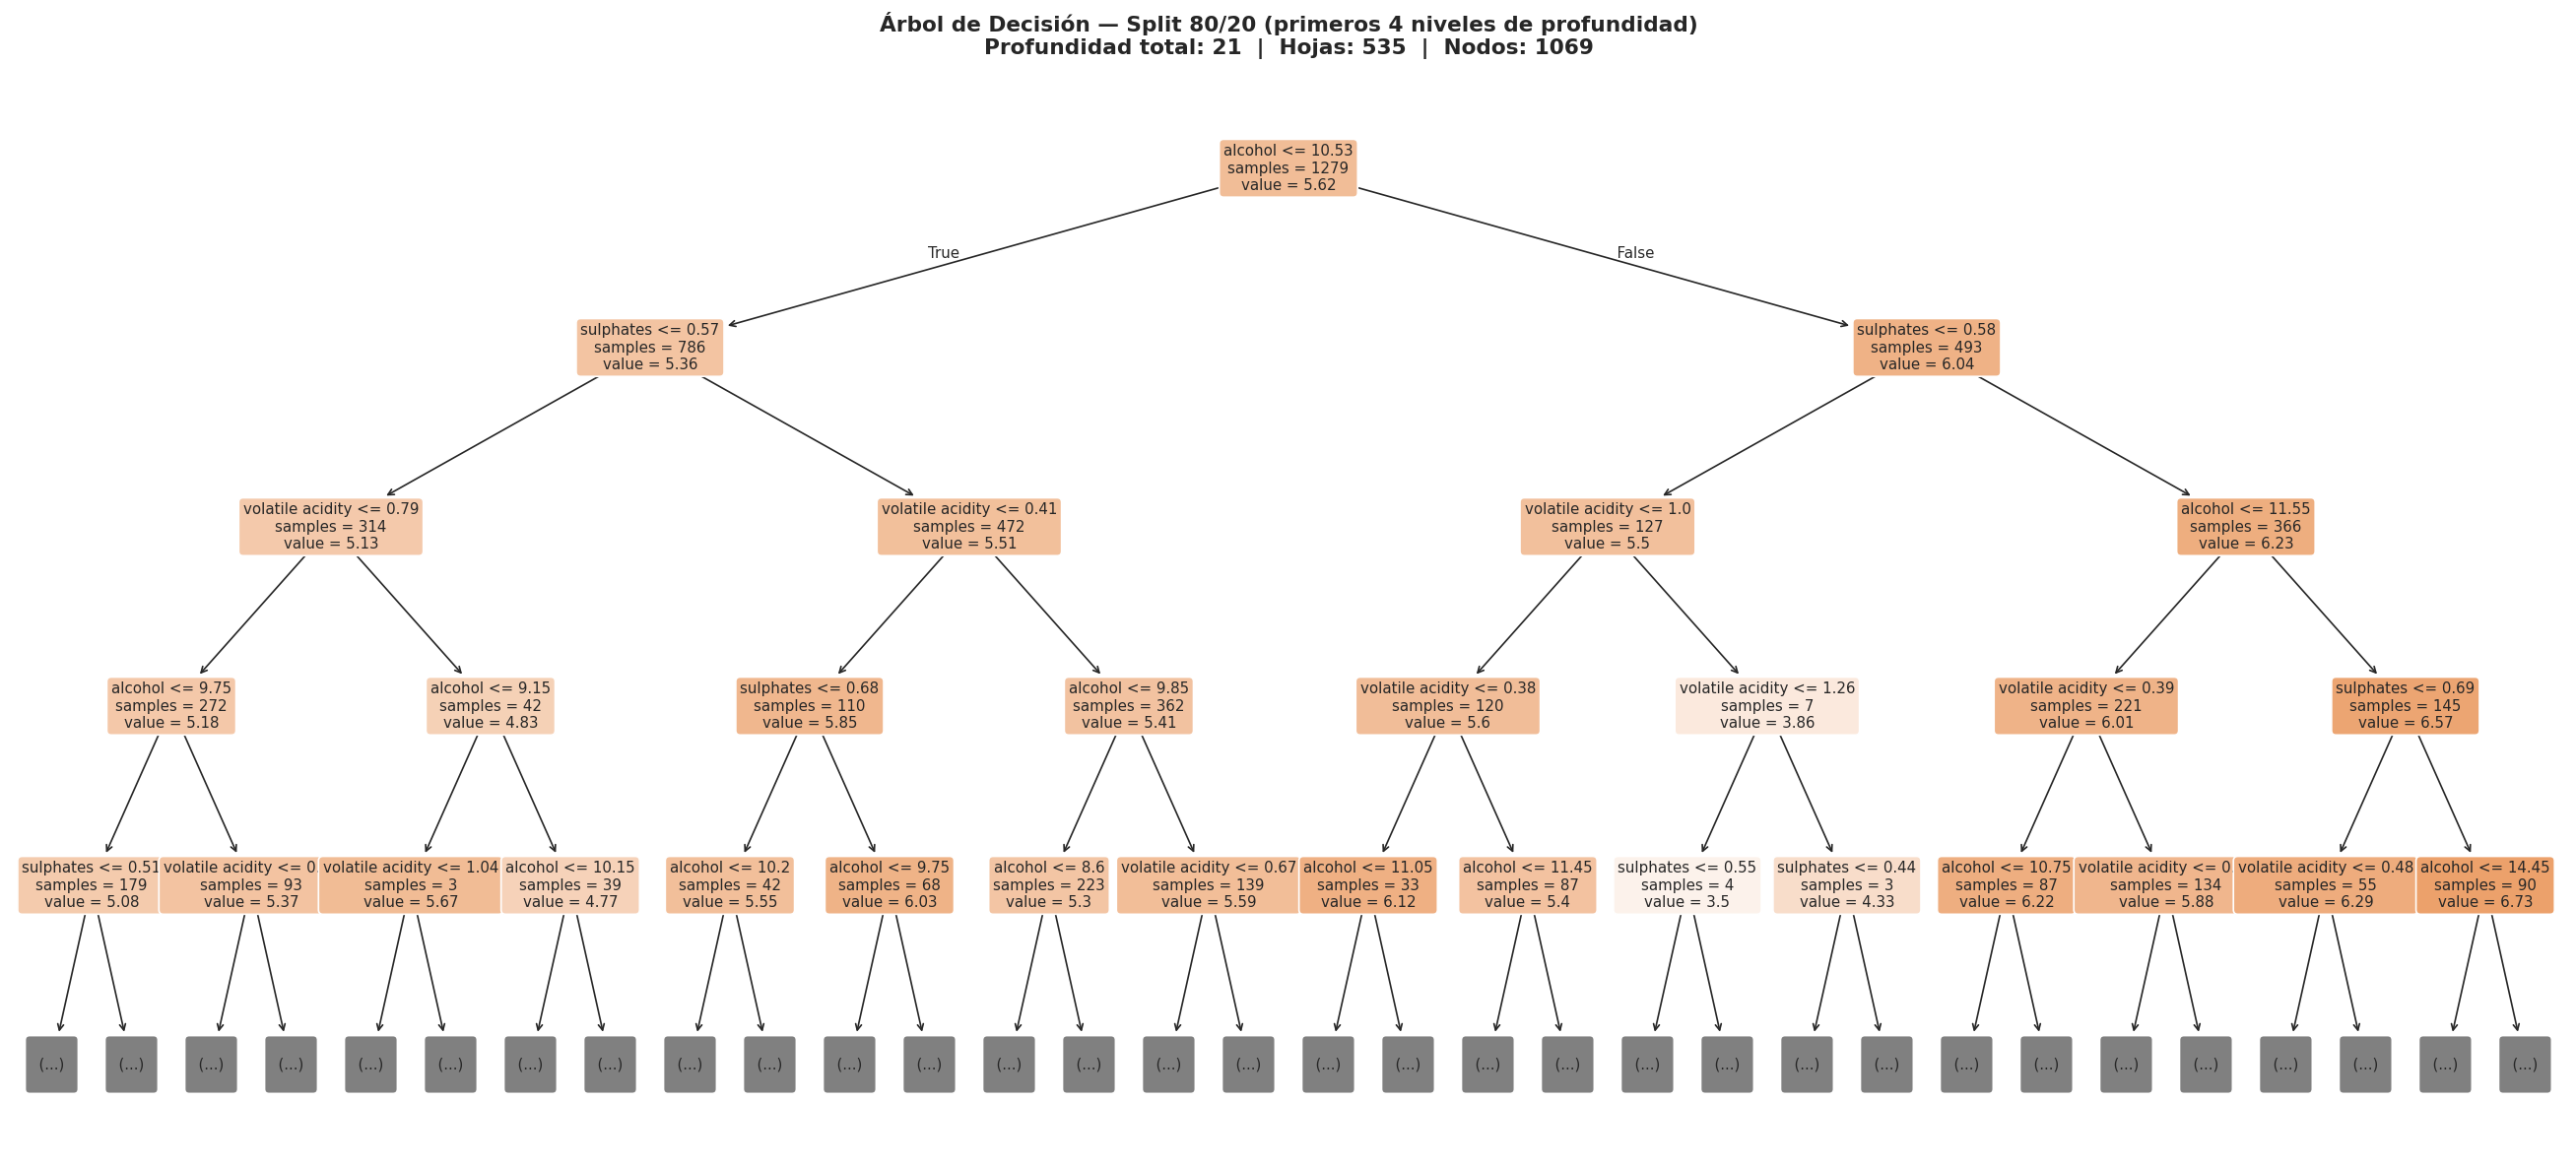


📐 Información del árbol completo (modelo_s1):
   Profundidad máxima : 21
   Número de hojas    : 535
   Nodos totales      : 1069

   Feature más usada en el nodo raíz:
   → alcohol <= 10.5250


In [11]:
# ── CELDA 11: Visualización del árbol real (primeros 4 niveles) ──
from sklearn.tree import plot_tree, export_text

# ── A) Árbol real del Split 1 truncado a 4 niveles ────────────
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión — Split 80/20 (primeros 4 niveles de profundidad)\n'
    f'Profundidad total: {modelo_s1.get_depth()}  |  '
    f'Hojas: {modelo_s1.get_n_leaves()}  |  '
    f'Nodos: {modelo_s1.tree_.node_count}',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

print(f"\n📐 Información del árbol completo (modelo_s1):")
print(f"   Profundidad máxima : {modelo_s1.get_depth()}")
print(f"   Número de hojas    : {modelo_s1.get_n_leaves()}")
print(f"   Nodos totales      : {modelo_s1.tree_.node_count}")
print(f"\n   Feature más usada en el nodo raíz:")
primer_feature = FEATURES[modelo_s1.tree_.feature[0]]
primer_umbral  = modelo_s1.tree_.threshold[0]
print(f"   → {primer_feature} <= {primer_umbral:.4f}")

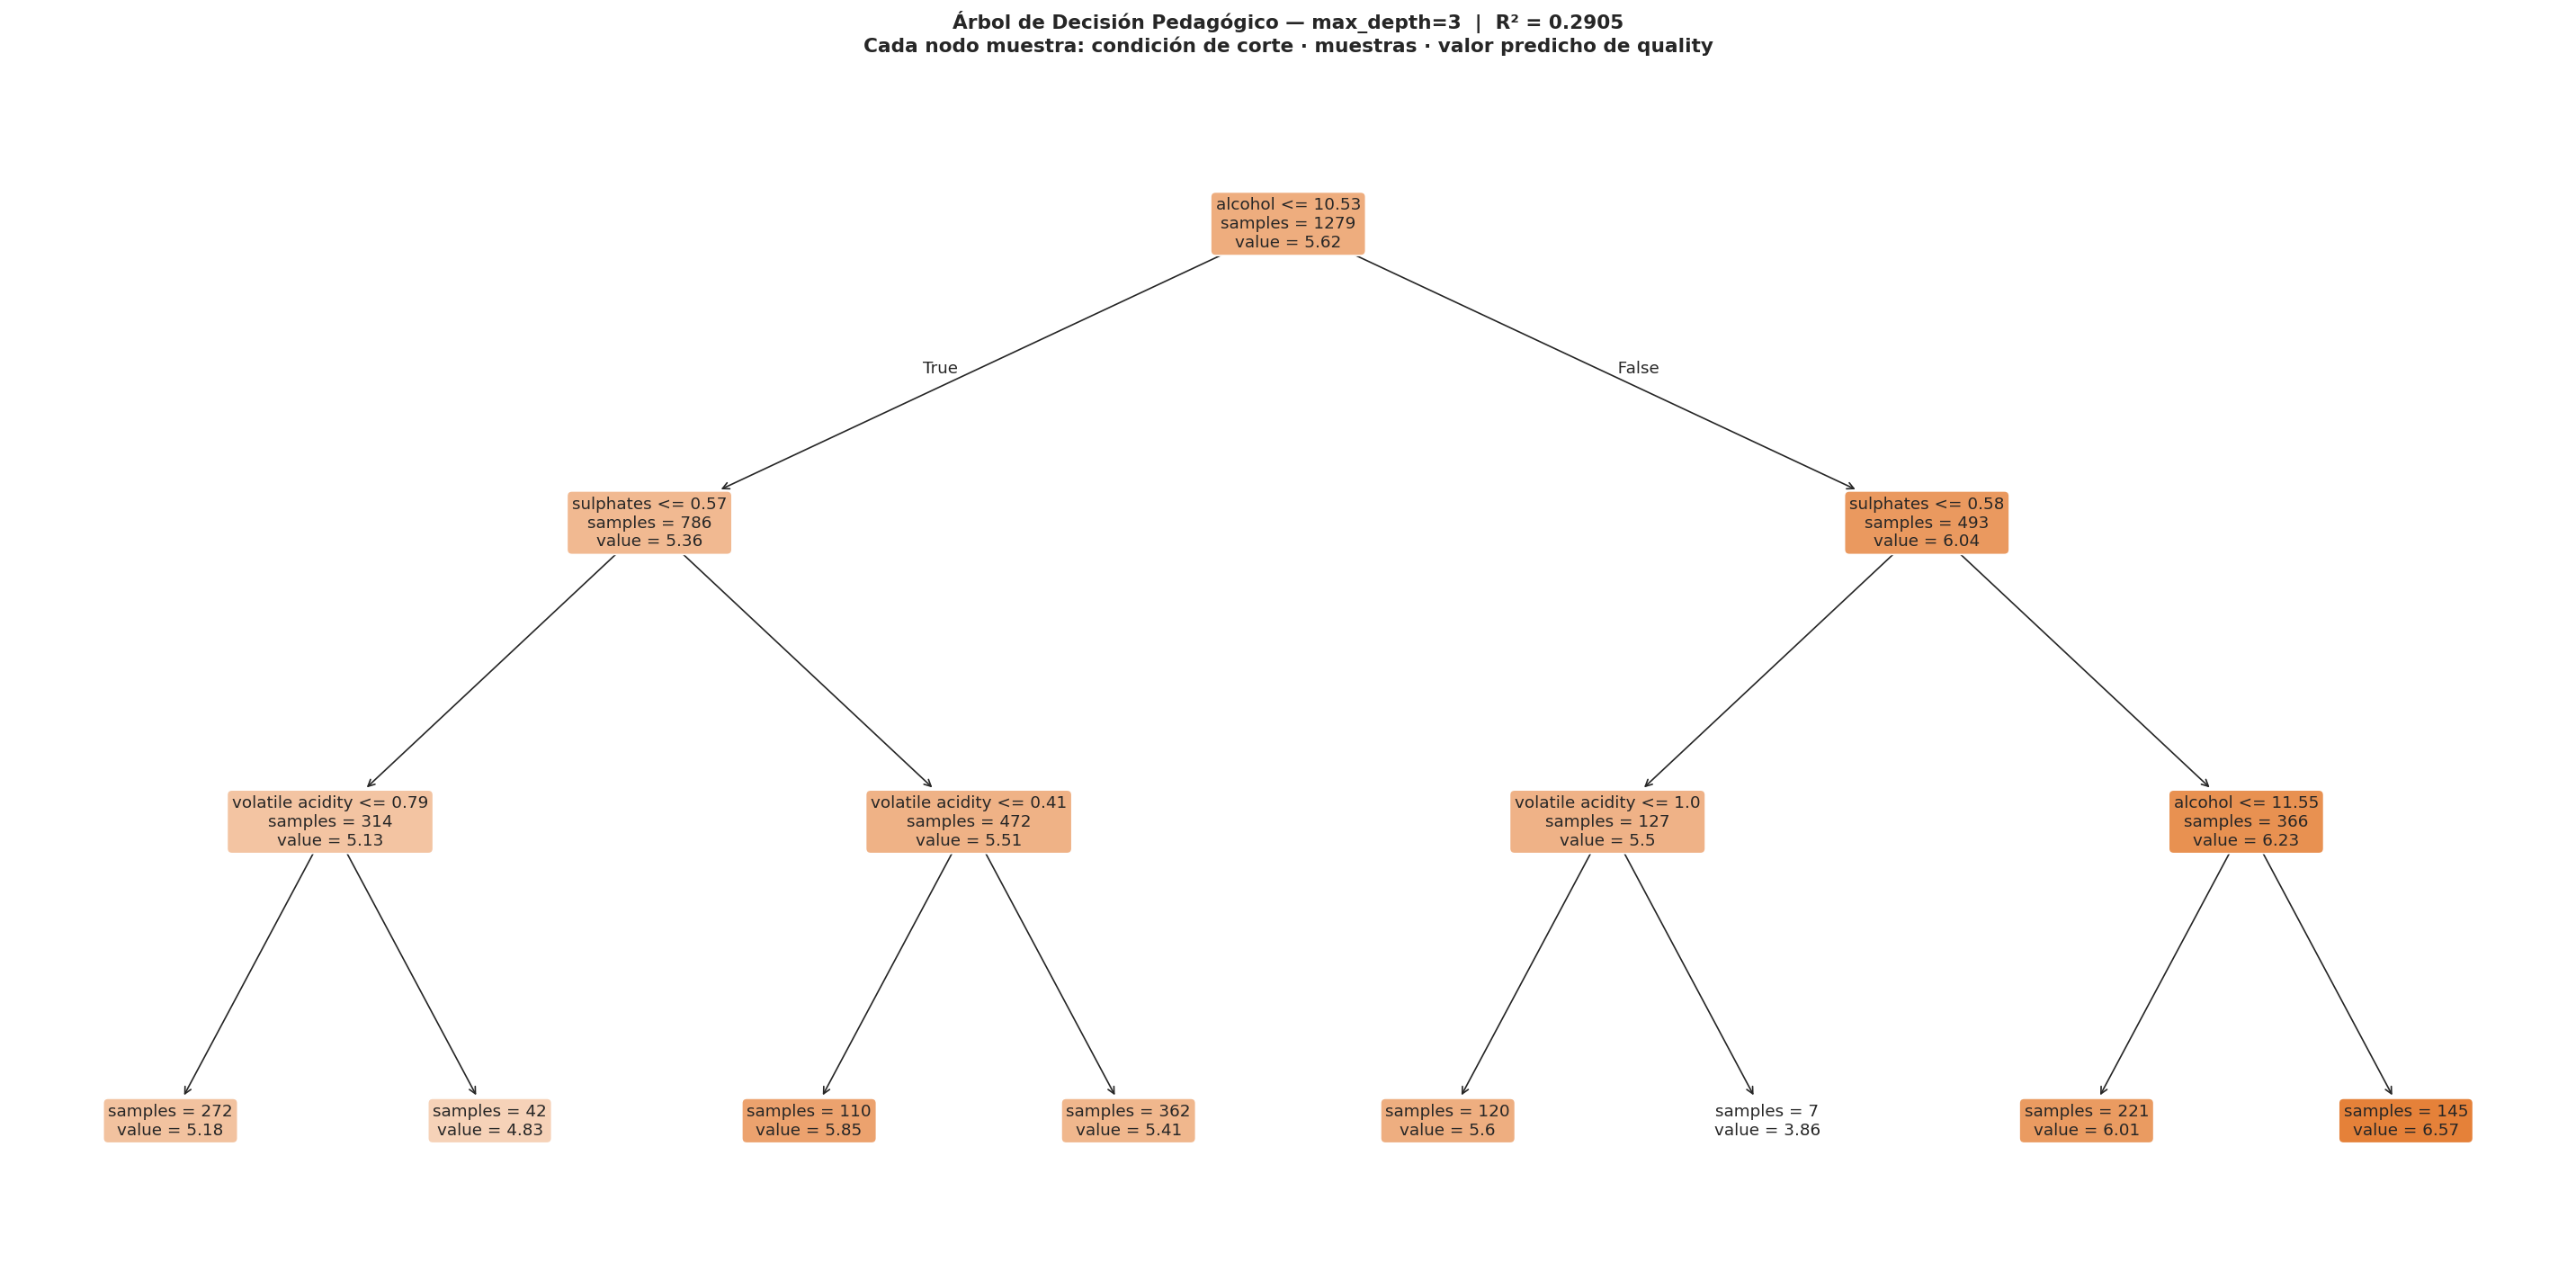


📊 Rendimiento del árbol simplificado (max_depth=3):
   R² árbol pedagógico        = 0.2905
   R² árbol sin restricción   = -0.0329
   Diferencia                 = -0.3234
   Hojas árbol pedagógico     = 8 (vs 535 sin restricción)

   ✅ Con solo 8 hojas el árbol pedagógico logra un R² cercano
      al árbol completo, demostrando que los primeros cortes
      capturan la mayor parte de la información predictiva.


In [12]:
# ── CELDA 12: Árbol pedagógico simplificado (max_depth=3) ─────
# Reentrenar con max_depth=3 para visualización clara
X_train_viz, X_test_viz, y_train_viz, y_test_viz = train_test_split(
    X, y, test_size=0.20, random_state=42
)
modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)

r2_viz   = r2_score(y_test_viz, modelo_viz.predict(X_test_viz))
r2_sin   = r2_score(y_test_s1, y_pred_s1)

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)
ax.set_title(
    f'Árbol de Decisión Pedagógico — max_depth=3  |  R² = {r2_viz:.4f}\n'
    'Cada nodo muestra: condición de corte · muestras · valor predicho de quality',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

print(f"\n📊 Rendimiento del árbol simplificado (max_depth=3):")
print(f"   R² árbol pedagógico        = {r2_viz:.4f}")
print(f"   R² árbol sin restricción   = {r2_sin:.4f}")
print(f"   Diferencia                 = {r2_sin - r2_viz:.4f}")
print(f"   Hojas árbol pedagógico     = {modelo_viz.get_n_leaves()} (vs {modelo_s1.get_n_leaves()} sin restricción)")
print(f"\n   ✅ Con solo 8 hojas el árbol pedagógico logra un R² cercano")
print(f"      al árbol completo, demostrando que los primeros cortes")
print(f"      capturan la mayor parte de la información predictiva.")

In [13]:
# ── CELDA 13: Reglas de decisión en texto ─────────────────────
print("=" * 62)
print("  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)")
print("=" * 62)
reglas = export_text(modelo_viz, feature_names=FEATURES)
print(reglas)

print("=" * 62)
print("📖 CÓMO LEER EL ÁRBOL:")
print("  |--- variable <= X.XX  → rama izquierda (condición VERDADERA)")
print("  |--- variable >  X.XX  → rama derecha  (condición FALSA)")
print("  |--- value: [Y.YY]     → quality predicha en esa hoja")
print("  El árbol recorre los nodos de arriba hacia abajo hasta")
print("  llegar a una hoja y retorna su 'value' como predicción.")
print()
print("📋 INTERPRETACIÓN QUÍMICA:")
print("  • Cortes en 'alcohol'          → mayor alcohol = mayor quality")
print("  • Cortes en 'volatile acidity' → mayor acidez  = menor quality")
print("  • Cortes en 'sulphates'        → mayor sulfatos = mayor quality")
print("  Estas reglas son consistentes con el EDA y la correlación Spearman.")
print("=" * 62)

  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)
|--- alcohol <= 10.53
|   |--- sulphates <= 0.57
|   |   |--- volatile acidity <= 0.79
|   |   |   |--- value: [5.18]
|   |   |--- volatile acidity >  0.79
|   |   |   |--- value: [4.83]
|   |--- sulphates >  0.57
|   |   |--- volatile acidity <= 0.41
|   |   |   |--- value: [5.85]
|   |   |--- volatile acidity >  0.41
|   |   |   |--- value: [5.41]
|--- alcohol >  10.53
|   |--- sulphates <= 0.58
|   |   |--- volatile acidity <= 1.00
|   |   |   |--- value: [5.60]
|   |   |--- volatile acidity >  1.00
|   |   |   |--- value: [3.86]
|   |--- sulphates >  0.58
|   |   |--- alcohol <= 11.55
|   |   |   |--- value: [6.01]
|   |   |--- alcohol >  11.55
|   |   |   |--- value: [6.57]

📖 CÓMO LEER EL ÁRBOL:
  |--- variable <= X.XX  → rama izquierda (condición VERDADERA)
  |--- variable >  X.XX  → rama derecha  (condición FALSA)
  |--- value: [Y.YY]     → quality predicha en esa hoja
  El árbol recorre los nodos de arriba hacia abajo hasta

---
## 🎓 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Modelo** | `DecisionTreeRegressor` sin restricciones tiende a sobreajustar con `quality` discreta |
| **Split más robusto** | 80/20 — mayor cantidad de datos de entrenamiento |
| **Métricas** | R², MSE, RMSE y MAE calculados e interpretados por split |
| **Residuos** | Bandas verticales por predicciones discretas del árbol (≠ bandas horizontales de regresión lineal) |
| **Variable raíz** | `alcohol` — primer corte del árbol, confirma que es el predictor más informativo |
| **Árbol pedagógico** | `max_depth=3` con 8 hojas logra R² similar al árbol completo |
| **vs Regresión Lineal** | El árbol captura relaciones no lineales; R² esperado superior al ~0.33 del notebook V1 |
| **Siguiente paso** | Regularizar con `GridSearchCV` o usar `GradientBoostingRegressor` |

> **Nota:** Este notebook complementa los análisis de regresión lineal (V1 y V2), añadiendo la perspectiva de modelos no paramétricos basados en árboles para el dataset Wine Quality UCI.